# Fallback model comparison

Compares all `tscglue.fallback` baselines (the `f-*` classifiers) on the four benchmark
metrics used in `066-benchmark-results.ipynb`: **Accuracy**, **LogLoss**, **F1** and **AUROC**.

Metrics are computed directly from the tsml-format prediction files with
`tsml_eval.evaluation.storage.load_classifier_results` instead of
`evaluate_classifiers_by_problem`, because the joint evaluation drops every dataset that is
missing for *any* classifier — with the partially-run fallback models that leaves nothing.
Here each comparison is restricted to the complete-case dataset intersection of the models
being compared.

In [8]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..")
MODEL_RESULTS = PROJECT_ROOT / "model_results"

fallback_models = sorted(
    p.name for p in MODEL_RESULTS.iterdir() if p.is_dir() and p.name.startswith("f-")
)
print("Fallback models:", fallback_models)

# metric -> lower is better
METRICS = {"Accuracy": False, "LogLoss": True, "F1": False, "AUROC": False}

Fallback models: ['f-AllFeaturesET', 'f-AllFeaturesRidge', 'f-MRHydraET', 'f-MRHydraLogistic', 'f-MRHydraRidge', 'f-MultiET', 'f-QuantET', 'f-ShapeDictET']


In [9]:
# Load every available result file and compute the four metrics
from tsml_eval.evaluation.storage import load_classifier_results

rows = []
for model in fallback_models:
    for f in sorted((MODEL_RESULTS / model / "Predictions").glob("*/testResample*.csv")):
        r = load_classifier_results(str(f))
        rows.append(
            {
                "model": model,
                "dataset": f.parent.name,
                "resample": int(f.stem.replace("testResample", "")),
                "Accuracy": r.accuracy,
                "LogLoss": r.log_loss,
                "F1": r.f1_score,
                "AUROC": r.auroc_score,
            }
        )

results = pd.DataFrame(rows)
print(f"{len(results)} result files loaded")
results.head()

2293 result files loaded


,model,dataset,resample,Accuracy,LogLoss,F1,AUROC
0,f-AllFeaturesET,ACSF1,0,0.940000,0.383145,0.938450,0.998111
1,f-AllFeaturesET,ACSF1,1,0.810000,0.574408,0.800009,0.989667
2,f-AllFeaturesET,ACSF1,4,0.910000,0.586310,0.908072,0.985889
3,f-AllFeaturesET,Adiac,0,0.820972,0.795904,0.818108,0.993749
4,f-AllFeaturesET,Adiac,1,0.805627,0.852894,0.801351,0.989534


In [10]:
# Coverage: result files per model x resample, and datasets covered per model
coverage = results.pivot_table(
    index="model", columns="resample", values="dataset", aggfunc="count"
).fillna(0).astype(int)
coverage["datasets"] = results.groupby("model")["dataset"].nunique()
display(coverage)

from aeon.datasets.tsc_datasets import univariate_equal_length

n_all = len(univariate_equal_length)
print(f"\nUCR univariate equal-length datasets: {n_all}")
for m in fallback_models:
    n = coverage.loc[m, "datasets"]
    if n < n_all:
        print(f"  {m:<22} only {n}/{n_all} datasets")

resample,0,1,4,datasets
model,,,,
f-AllFeaturesET,112,112,112,112
f-AllFeaturesRidge,94,86,95,112
f-MRHydraET,112,112,112,112
f-MRHydraLogistic,1,0,1,2
f-MRHydraRidge,112,112,112,112
f-MultiET,112,112,112,112
f-QuantET,112,112,112,112
f-ShapeDictET,112,112,112,112



UCR univariate equal-length datasets: 112
  f-MRHydraLogistic      only 2/112 datasets


In [11]:
# Average over available resamples per (model, dataset)
per_dataset = results.groupby(["model", "dataset"])[list(METRICS)].mean().reset_index()


def complete_case(models, metric):
    """Dataset x model matrix restricted to datasets every model has results for."""
    mat = per_dataset[per_dataset["model"].isin(models)].pivot(
        index="dataset", columns="model", values=metric
    )
    return mat.dropna()


# Models with results on at least half the covered datasets get their own, larger comparison
n_datasets = per_dataset.groupby("model")["dataset"].nunique()
well_covered = sorted(n_datasets[n_datasets >= 0.5 * n_datasets.max()].index)
sparse = sorted(set(fallback_models) - set(well_covered))
print("Well-covered models:", well_covered)
print("Sparse models      :", sparse)

GROUPS = {
    "all fallback models": fallback_models,
    "well-covered fallback models": well_covered,
}
for name, models in GROUPS.items():
    print(f"{name}: complete-case intersection = {len(complete_case(models, 'Accuracy'))} datasets")

Well-covered models: ['f-AllFeaturesET', 'f-AllFeaturesRidge', 'f-MRHydraET', 'f-MRHydraRidge', 'f-MultiET', 'f-QuantET', 'f-ShapeDictET']
Sparse models      : ['f-MRHydraLogistic']
all fallback models: complete-case intersection = 2 datasets
well-covered fallback models: complete-case intersection = 112 datasets


## Summary tables

Mean over the complete-case dataset intersection of each group, plus the mean rank
(rank 1 = best on a dataset; LogLoss is ranked ascending).

In [12]:
for name, models in GROUPS.items():
    mats = {metric: complete_case(models, metric) for metric in METRICS}
    n = len(mats["Accuracy"])
    if n == 0:
        print(f"{name}: no common datasets, skipping\n")
        continue

    mean_tbl = pd.DataFrame({metric: mat.mean() for metric, mat in mats.items()})
    rank_tbl = pd.DataFrame(
        {
            f"{metric} rank": mat.rank(
                axis=1, ascending=lower_better
            ).mean()
            for (metric, lower_better), mat in zip(METRICS.items(), mats.values())
        }
    )
    print(f"{name} ({n} common datasets)")
    display(
        mean_tbl.join(rank_tbl)
        .sort_values("Accuracy rank")
        .round(4)
    )

all fallback models (2 common datasets)


,Accuracy,LogLoss,F1,AUROC,Accuracy rank,LogLoss rank,F1 rank,AUROC rank
model,,,,,,,,
f-MRHydraRidge,0.9972,0.2302,0.9972,1.0000,2.75,8.0,2.75,2.75
f-AllFeaturesRidge,0.9917,0.2223,0.9917,0.9999,3.50,7.0,3.75,3.25
f-ShapeDictET,0.9917,0.0674,0.9918,0.9998,3.50,2.0,3.25,3.75
f-MultiET,0.9889,0.0642,0.9891,0.9996,4.25,1.0,4.25,5.25
f-AllFeaturesET,0.9889,0.0707,0.9890,0.9996,5.00,3.0,5.00,4.50
f-QuantET,0.9889,0.0810,0.9890,0.9995,5.00,5.0,5.00,5.75
f-MRHydraLogistic,0.9833,0.0837,0.9831,0.9948,5.75,5.0,5.75,6.25
f-MRHydraET,0.9806,0.0854,0.9806,0.9996,6.25,5.0,6.25,4.50


well-covered fallback models (112 common datasets)


,Accuracy,LogLoss,F1,AUROC,Accuracy rank,LogLoss rank,F1 rank,AUROC rank
model,,,,,,,,
f-AllFeaturesRidge,0.8877,0.8011,0.8719,0.9607,2.5938,5.8036,2.4821,3.5312
f-MRHydraRidge,0.8862,0.8084,0.8717,0.9590,2.8438,5.9464,2.7009,4.0893
f-AllFeaturesET,0.8744,0.4559,0.8553,0.9624,3.7902,2.2411,3.8884,3.2009
f-MultiET,0.8742,0.4539,0.8549,0.9624,3.9330,2.1875,3.8884,3.3170
f-QuantET,0.8565,0.5120,0.8366,0.9570,4.8929,4.1696,4.8884,4.8482
f-ShapeDictET,0.8673,0.5076,0.8466,0.9589,4.9330,4.3036,5.0446,4.4598
f-MRHydraET,0.8652,0.4786,0.8455,0.9583,5.0134,3.3482,5.1071,4.5536


## Critical-difference diagrams

One per metric, on the complete-case intersection of each group. Groups whose
intersection is too small for the Wilcoxon-Holm test are skipped with a note.

Accuracy — all fallback models: only 2 common datasets (< 5), skipping CD diagram
LogLoss — all fallback models: only 2 common datasets (< 5), skipping CD diagram
F1 — all fallback models: only 2 common datasets (< 5), skipping CD diagram
AUROC — all fallback models: only 2 common datasets (< 5), skipping CD diagram


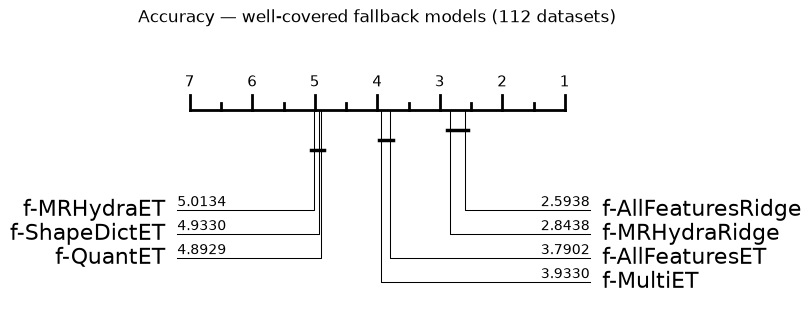

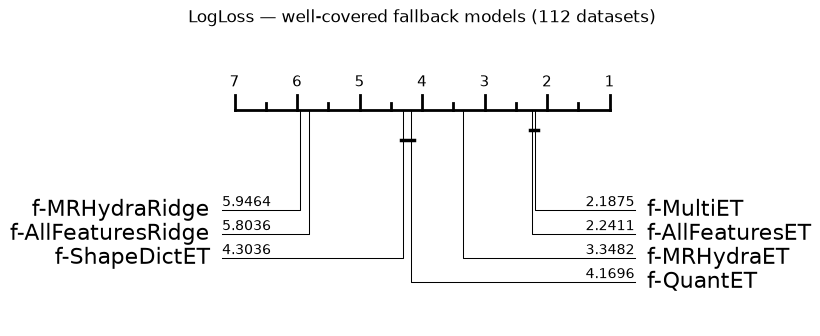

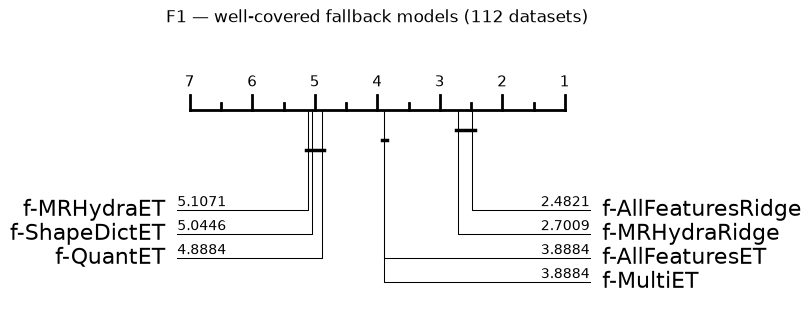

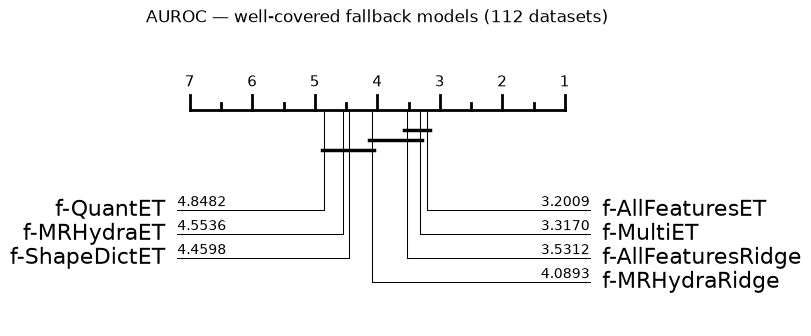

In [13]:
import matplotlib.pyplot as plt
from aeon.visualisation import plot_critical_difference

MIN_DATASETS = 5

for name, models in GROUPS.items():
    for metric, lower_better in METRICS.items():
        mat = complete_case(models, metric)
        if len(mat) < MIN_DATASETS:
            print(
                f"{metric} — {name}: only {len(mat)} common datasets "
                f"(< {MIN_DATASETS}), skipping CD diagram"
            )
            continue
        fig, ax = plot_critical_difference(
            mat.values, list(mat.columns), lower_better=lower_better
        )
        ax.set_title(f"{metric} — {name} ({len(mat)} datasets)", pad=20)
        plt.show()
        plt.close(fig)

## Per-dataset distributions

Boxplots of the per-dataset metric values on the well-covered group's common datasets.

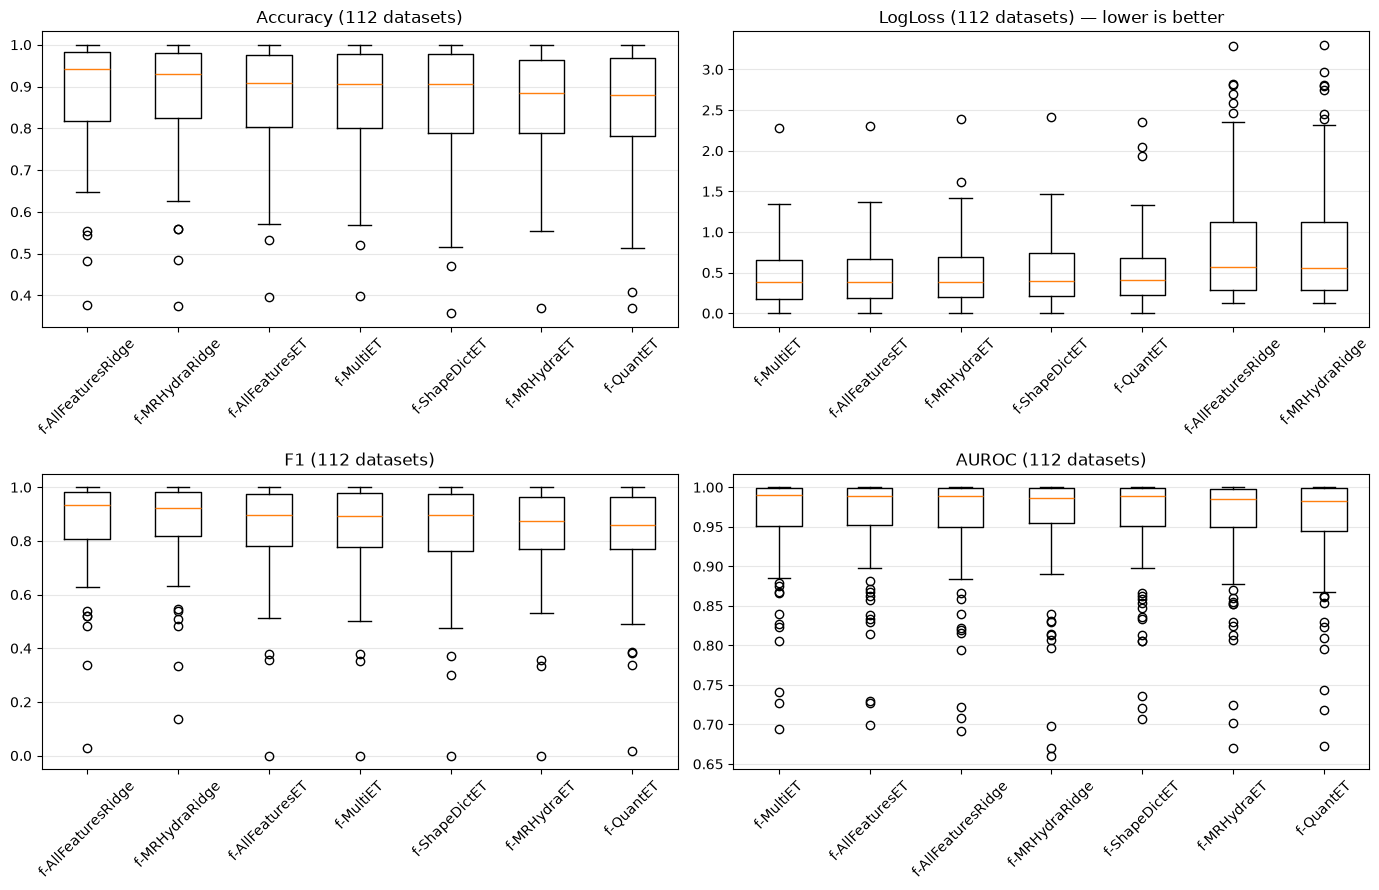

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (metric, lower_better) in zip(axes.flat, METRICS.items()):
    mat = complete_case(well_covered, metric)
    order = mat.mean().sort_values(ascending=lower_better).index
    ax.boxplot([mat[m] for m in order], tick_labels=order)
    ax.set_title(f"{metric} ({len(mat)} datasets)" + (" — lower is better" if lower_better else ""))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()